# Phase 2 — Predicting Negative Reviews: Logistic Regression vs Random Forest

**The question:** right after an order is delivered, can we predict whether the customer will leave a **negative review** (1–2 stars)? If we can, customer service can work through a daily contact list of the riskiest orders *before* those customers write their review.

**What this notebook does:** it compares two model families, plus a simple business rule as a benchmark. Each family starts from its **simplest version** and steps up in complexity, and every step has to prove it is worth it.

| | Model | Family | Version |
|---|---|---|---|
| R | "Flag the latest deliveries" rule | Benchmark | No model: rank orders by how late they arrived |
| A | Logistic Regression | Linear | Plain: no regularisation, no class weighting |
| B | Logistic Regression | Linear | Tuned |
| C | Decision Tree | Tree-based | A single tree, default settings |
| D | Random Forest | Tree-based | 200 trees, default settings (no tuning) |
| E | Random Forest | Tree-based | Tuned |

**Two design choices drive everything below:**

* **Time-based validation.** Models learn from **earlier orders** and are tested on **later orders**, as they would be in real use. Our Phase 1 literature review warns that random splits of time-ordered data cause temporal leakage and overestimate performance, and the professor lists it as a pitfall.
* **Top-10% precision decides the winner.** Customer service works a fixed daily contact list, so Phase 1 committed to judging the model on *"precision among its top-ranked orders"*. We rank orders by risk and ask: of the riskiest 10%, how many really leave a negative review?

**How to read this notebook.** Every step explains **what we are doing** and **why**, in plain English. Every result is followed by **What this tells us**. Some steps also have a **Likely question** with an answer you can use to defend the approach.

**The steps**

1. Load the data
2. Build the modelling table
3. Split by time: learn from the past, test on the future
4. Prepare the inputs for the models
5. Meet the models and the benchmark rule
6. How we score models, cross-validation and tuning
7. Cross-validation results: pick the winner
8. The final exam: results on later orders, plus train vs validation vs test
9. Does each step up in complexity help, and do the models beat the rule?
10. What do the models rely on?
11. Error analysis: where does the model go wrong?
12. How much would a random split have flattered the models?
13. Final comparison: tuned Logistic Regression vs tuned Random Forest
14. A note on the saved model files

The report write-up (problem statement and stakeholder, data cleaning, feature engineering, insights and limitations) is in [`docs/Phase2_Classification_Report_Sections.docx`](../docs/Phase2_Classification_Report_Sections.docx).

> **Runtime:** about 10–15 minutes on a 12-core laptop (10 minutes on the last run). Most of it is the Random Forest tuning in step 6.

## Step 1. Load the data

**What we are doing:** loading two tables prepared and cleaned in Phase 1:

* `order_level.csv`: **one row per order**, with delivery dates, payment, customer location and the review score.
* `item_level.csv`: **one row per product inside an order**, with price, category and product size.

**Why:** both model families start from exactly the same, already-checked data, so any difference in results comes from the models themselves.

In [1]:
from pathlib import Path
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from IPython.display import display
from sklearn.base import clone
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    average_precision_score,
    balanced_accuracy_score,
    f1_score,
    make_scorer,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit, cross_validate, train_test_split

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.classification_data import (
    DELIVERED_MODEL_FEATURES,
    DELIVERED_NUMERIC_FEATURES,
    TARGET_COLUMN,
    build_delivered_order_classification_dataset,
    split_delivered_order_features_target,
)
from src.classification_model import build_delivered_order_logistic_pipeline
from src.classification_tree_model import (
    build_delivered_order_decision_tree_pipeline,
    build_delivered_order_random_forest_pipeline,
)

RANDOM_SEED = 42
THRESHOLD = 0.50
TOP_SHARE = 0.10
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
notebook_started = time.perf_counter()

order_level = pd.read_csv(PROCESSED_DIR / "order_level.csv")
item_level = pd.read_csv(PROCESSED_DIR / "item_level.csv")

print(f"order_level: {order_level.shape[0]:,} rows × {order_level.shape[1]} columns")
print(f"item_level: {item_level.shape[0]:,} rows × {item_level.shape[1]} columns")
print(f"scikit-learn version: {sklearn.__version__}")

order_level: 99,441 rows × 36 columns
item_level: 112,650 rows × 20 columns
scikit-learn version: 1.9.0


## Step 2. Build the modelling table

**What we are doing:** turning the two tables into **one row per order**, with 21 input columns (the clues) and one answer column (the **target**):

* target = **1** if the review was 1–2 stars (negative)
* target = **0** if the review was 3–5 stars

We keep only orders that were **delivered**, have a **delivery date** and have a **review**. A model can only learn from orders whose outcome we know.

**Why only these inputs:** we make the prediction **right after delivery, before the review exists**. Delivery information (how late, how long it took) is allowed, because we know it at that moment, although step 2.1 shows an important exception for late orders. Anything from the review itself is not allowed. Using it would be **leakage**, like marking an exam with the answer sheet in view: the model would look brilliant in testing but could never work in real life. The team's code in `src/classification_data.py` enforces this, and stops with an error if the data breaks its rules.

In [2]:
delivered_at = pd.to_datetime(order_level["order_delivered_customer_date"], errors="coerce")
population_masks = [
    ("All orders", pd.Series(True, index=order_level.index)),
    ("Delivered status", order_level["order_status"].eq("delivered")),
    ("Delivery date present", delivered_at.notna()),
    ("Review recorded", order_level["review_score"].notna()),
]
eligible_so_far = pd.Series(True, index=order_level.index)
audit_rows = []
for stage, stage_mask in population_masks:
    eligible_so_far &= stage_mask
    audit_rows.append({"filter": stage, "orders_remaining": int(eligible_so_far.sum())})
display(pd.DataFrame(audit_rows))

classification_data = build_delivered_order_classification_dataset(order_level, item_level)
lookup = order_level.set_index("order_id").loc[classification_data["order_id"]]
classification_data["purchase_time"] = pd.to_datetime(lookup["order_purchase_timestamp"], format="mixed").to_numpy()

display(
    classification_data[TARGET_COLUMN]
    .value_counts()
    .rename(index={0: "Review 3–5 (target 0)", 1: "Negative review 1–2 (target 1)"})
    .rename("orders")
    .to_frame()
    .assign(share=lambda table: (table["orders"] / table["orders"].sum()).round(3))
)
display(pd.DataFrame({
    "input": DELIVERED_MODEL_FEATURES,
    "type": ["number" if name in DELIVERED_NUMERIC_FEATURES else "category" for name in DELIVERED_MODEL_FEATURES],
}))

assert classification_data["order_id"].is_unique
assert "order_id" not in DELIVERED_MODEL_FEATURES
assert not any(name.startswith("review_") for name in DELIVERED_MODEL_FEATURES)

,filter,orders_remaining
0,All orders,99441
1,Delivered status,96478
2,Delivery date present,96470
3,Review recorded,95824


,orders,share
is_negative_review,,
Review 3–5 (target 0),83552,0.872
Negative review 1–2 (target 1),12272,0.128


,input,type
0,item_count,number
1,order_item_value,number
2,order_freight_value,number
3,seller_count,number
4,payment_total,number
5,payment_count,number
6,max_installments,number
7,freight_share,number
8,delivery_days,number
9,days_early,number


### What this tells us

* **95,824 orders** can be used to train and test the models.
* Only **12.8% (12,272) are negative reviews**, roughly 1 in 7. This is called **class imbalance**, and it matters a lot. A lazy "model" that always says "not negative" would be right 87% of the time and still be useless, because it never finds an unhappy customer. That is why this notebook **never judges a model on accuracy alone**.
* The `assert` lines at the end of the cell prove in code that no order ID and no review field is used as an input.

### 2.1 ⚠️ Known issue under team review: some reviews are written before delivery

**What we are checking:** our prediction point assumes the review comes *after* delivery. In Olist, though, the review request can go out around the **promised** delivery date even if the parcel has not arrived yet. The cell below counts how often the review was actually written **before** the order was delivered.

**Why it matters:** for those orders, the delivery inputs (`delivery_days`, `days_early`, `late_delivery_flag`) describe a delivery that happened *after* the review. That information was not available when the outcome was decided, which is a form of **leakage**. Because those reviews are mostly negative, it can make the timing inputs look more powerful than they would be in real use. Kapoor & Narayanan (2023), from our Phase 1 review, show that fixing leakage can remove a complex model's advantage over a simple one.

In [3]:
reviewed_at = pd.to_datetime(lookup["review_answer_timestamp"], format="mixed")
delivered = pd.to_datetime(lookup["order_delivered_customer_date"], format="mixed")
reviewed_before_delivery = (reviewed_at < delivered).to_numpy()
is_late = classification_data["late_delivery_flag"].eq(1).to_numpy()
is_negative = classification_data[TARGET_COLUMN].eq(1).to_numpy()

print(f"Orders reviewed before delivery: {reviewed_before_delivery.sum():,} ({reviewed_before_delivery.mean():.1%} of all orders)")
print(f"  share of LATE orders reviewed before delivery: {reviewed_before_delivery[is_late].mean():.1%}")
print(f"  share of on-time or early orders reviewed before delivery: {reviewed_before_delivery[~is_late].mean():.1%}")
print(f"  negative-review rate among them: {is_negative[reviewed_before_delivery].mean():.1%} (vs {is_negative[~reviewed_before_delivery].mean():.1%} for the rest)")
print(f"  share of ALL negative reviews that were written before delivery: {reviewed_before_delivery[is_negative].mean():.1%}")

Orders reviewed before delivery: 4,653 (4.9% of all orders)
  share of LATE orders reviewed before delivery: 70.1%
  share of on-time or early orders reviewed before delivery: 0.2%
  negative-review rate among them: 78.3% (vs 9.5% for the rest)
  share of ALL negative reviews that were written before delivery: 29.7%


### What this tells us

* **4,653 orders (4.9%) were reviewed before they were delivered**, and almost all of them were late: **70.1% of late orders** were reviewed before delivery, against 0.2% of on-time or early orders.
* These reviews are mostly negative (**78.3%**, against 9.5% for the rest), and they make up **29.7% of all negative reviews**.
* For these orders, the delivery inputs come from *after* the review was written. The models in this notebook still include them, so their reliance on lateness, and their scores on late orders, are likely to be **somewhat optimistic**.
* **Status: the team is deciding how to handle this.** The options are: (a) drop these orders, since they cannot be acted on at the delivery-time prediction point anyway; (b) move the prediction point earlier, to the promised delivery date; or (c) keep them and report this as a limitation. The results below will be updated once the team decides.

## Step 3. Split by time: learn from the past, test on the future

**What we are doing:** sorting the orders by **purchase date**. The **earliest 80%** become the training set, and the **latest 20%** become the test set, the "final exam".

**Why:** in real use, a model is trained on past orders and used on future ones. If we mixed old and new orders randomly, the model could learn from orders placed *after* the ones it is tested on, a form of peeking into the future that makes it look better than it really is. Our Phase 1 literature review warns that random splits of time-ordered data cause exactly this **temporal leakage** and overestimate performance. Step 12 measures how big the effect is here.

**The trade-off:** a time split cannot force both parts to have the same share of negative reviews, because that share changes over time. The table below shows how it moves from quarter to quarter.

**Likely question:** *"The professor says to use stratified splits for imbalanced data. Why not here?"* **Answer:** stratifying means shuffling orders across time, which reintroduces the temporal leakage. We keep the imbalance under control in other ways: metrics that focus on the negative reviews (step 6), and class weighting as a tuning option (step 5).

In [4]:
classification_data = classification_data.sort_values("purchase_time", kind="stable").reset_index(drop=True)
X, y = split_delivered_order_features_target(classification_data)
purchase_time = classification_data["purchase_time"]

n_train = int(len(X) * 0.80)
X_train, X_test = X.iloc[:n_train], X.iloc[n_train:]
y_train, y_test = y.iloc[:n_train], y.iloc[n_train:]

for label, part, target, times in [
    ("Training set", X_train, y_train, purchase_time.iloc[:n_train]),
    ("Test set", X_test, y_test, purchase_time.iloc[n_train:]),
]:
    print(f"{label}: {len(part):,} orders, {times.min().date()} to {times.max().date()}; "
          f"negative-review rate {target.mean():.1%}; delivered late {part['late_delivery_flag'].mean():.1%}")
print(f"Negative : not-negative ratio in training = 1 : {(y_train == 0).sum() / (y_train == 1).sum():.1f}")

print("\nBy purchase quarter")
display(
    pd.DataFrame({
        "quarter": purchase_time.dt.to_period("Q").astype(str),
        "negative": y.to_numpy(),
        "late": X["late_delivery_flag"].to_numpy(),
    })
    .groupby("quarter")
    .agg(orders=("negative", "size"), negative_rate=("negative", "mean"), late_share=("late", "mean"))
    .round(3)
    .T
)

Training set: 76,659 orders, 2016-09-15 to 2018-05-27; negative-review rate 13.6%; delivered late 7.5%
Test set: 19,165 orders, 2018-05-27 to 2018-08-29; negative-review rate 9.7%; delivered late 3.4%
Negative : not-negative ratio in training = 1 : 6.4

By purchase quarter


quarter,2016Q3,2016Q4,2017Q1,2017Q2,2017Q3,2017Q4,2018Q1,2018Q2,2018Q3
orders,1.0,263.000,4911.000,8918.000,12125.000,17144.000,20468.000,19546.000,12448.000
negative_rate,1.0,0.163,0.113,0.110,0.099,0.145,0.180,0.109,0.096
late_share,1.0,0.008,0.036,0.038,0.033,0.086,0.127,0.041,0.047


### What this tells us

### What this tells us

* **Training set:** 76,659 orders bought between 15 September 2016 and 27 May 2018. **Test set:** 19,165 orders bought between 27 May and 29 August 2018.
* **The two periods are genuinely different.** The test period has fewer negative reviews (9.7% vs 13.6%) and far fewer late deliveries (3.4% vs 7.5%). The quarterly table shows why: early 2018 was a bad period (18.0% negative reviews and 12.7% late deliveries in Q1 2018), and things improved afterwards.
* **This matters for reading the scores later.** With fewer unhappy customers in the test period, every model's precision will be lower there than in training, even if the model is just as good. That is what the future actually looked like, not a flaw of the split.

## Step 4. Prepare the inputs for the models

**What we are doing:** models can only work with numbers and cannot handle gaps. Three things happen automatically inside each model's **pipeline**:

1. **Gaps are filled.** A missing number gets the **median** (the middle value); a missing category gets the **most common value**. The table below shows how few gaps there are.
2. **Categories become 0/1 columns** (one-hot encoding). For example, `customer_state` becomes one column per state, such as "is the customer in SP? 1 or 0". This turns the 21 inputs into many more model columns.
3. **Numbers are rescaled, for Logistic Regression only.** Rescaling stops a column measured in grams from drowning out one measured in days. Tree-based models do not need it, because a tree only asks questions like "is it more than 20 days?".

**Why inside a pipeline:** the fill-in values and the scaling are learned **from the training data only**, and the same steps are then applied to new orders. Nothing about the test set can leak into training.

In [5]:
missing = X_train.isna().sum()
missing = missing[missing > 0]
display(pd.DataFrame({
    "missing_orders": missing,
    "missing_percent": (missing / len(X_train) * 100).round(2),
    "filled_with": ["median" if name in DELIVERED_NUMERIC_FEATURES else "most common value" for name in missing.index],
}))

encoded_columns = (
    build_delivered_order_logistic_pipeline(random_state=RANDOM_SEED)
    .named_steps["preprocessor"]
    .fit(X_train)
    .get_feature_names_out()
)
print(f"{len(DELIVERED_MODEL_FEATURES)} inputs → {len(encoded_columns)} model columns after turning categories into 0/1 columns")

,missing_orders,missing_percent,filled_with
payment_total,1,0.00,median
payment_count,1,0.00,median
max_installments,1,0.00,median
product_weight_g_mean,16,0.02,median
product_volume_cm3_mean,16,0.02,median
product_photos_qty_mean,1236,1.61,median
primary_product_category,1236,1.61,most common value


21 inputs → 166 model columns after turning categories into 0/1 columns


### What this tells us

* Only 7 of the 21 inputs have any gaps, and the biggest gap is **1.61%** of training orders (product photos and product category, missing for the same orders). Simple filling is enough, and no orders need to be thrown away.
* The 21 inputs become **166 model columns**. The three latest purchase months (June–August 2018) only appear in the test period, so the model has never seen them and simply ignores them.

## Step 5. Meet the models and the benchmark rule

### R — the benchmark rule: "flag the latest deliveries"

Before building any model, we set a **simple business rule** that every model must beat. It ranks orders by **how late they arrived** against the promised date, latest first. With the 0.50 cut-off it flags every late order. It needs no training at all.

**Why:** our Phase 1 literature review recommends benchmarking against the platform's own delivery promise, and Kapoor & Narayanan (2023) show that simple baselines are the honest test of whether a complex model adds anything. Phase 1 also found that satisfaction drops sharply from the very first day an order is late. So if a model cannot beat "contact the latest deliveries", it is not worth building.

### Family 1 — Logistic Regression: a weighted checklist

Logistic Regression gives **every input a weight**. For each order it adds up *weight × value* across all inputs, then squeezes the total into a **risk score between 0 and 1**. A positive weight pushes the risk up; a negative weight pushes it down.

* **Strength:** simple, fast, and easy to explain ("late delivery raises the odds of a bad review by X%").
* **Weakness:** each input can only push in one fixed direction. It cannot easily learn "risk only jumps once an order is late", or "late *and* from several sellers is especially bad".

**A. Plain Logistic Regression** is the simplest version: no **regularisation** (nothing holds the weights back, set with `C = infinity`) and no class weighting. scikit-learn's default is *not* plain, because it already holds the weights back a little (`C = 1`). So we switch that off to get a true baseline. **B** is the tuned version (step 6).

### Family 2 — Decision Tree → Random Forest

**C. A single decision tree** is a flowchart learned from data. It asks yes/no questions about an order, such as *"Was it late?" → "Did it take more than 20 days?"*. Each end-point holds the share of negative reviews among the training orders that landed there. It is the simplest tree-based model and the family's baseline. Left to grow freely, one tree tends to **memorise** the training orders (**overfitting**).

**D. A Random Forest** grows **200 different trees**. Each tree sees a random sample of orders and, at each question, may only choose from a random handful of inputs. The forest's risk score is the **average of all 200 trees**. Individual trees make different mistakes, and averaging cancels much of that noise. **E** is the tuned forest (step 6).

* **Strength:** learns thresholds and combinations automatically.
* **Weakness:** harder to explain, slower to train, and a much bigger model file.

### The class-imbalance option: class weighting

Because only about 1 in 7 orders is negative, a model left alone learns to be cautious. **Class weighting** tells the model that a missed negative review counts about **7× as much** as a happy customer wrongly flagged. This is **cost-sensitive learning**, which Kandula et al. (2021) found effective. We do not resample the data, because van den Goorbergh et al. (2022) show that resampling distorts the risk scores without improving ranking. Whether to use class weighting is **one of the settings we tune**.

### Simplest version first

Every model has **settings** (called **hyperparameters**) that are chosen *before* training, like the knobs on an oven. **Tuning** means trying many settings and keeping the best (step 6).

**Why start simple:** the project brief says to start with the simplest version in each family as a **baseline**, and that each more complex version must **prove** it is better. Step 9 checks every step up: A → B, C → D, D → E, and the best model against the rule.

**Likely question:** *"Why these two model families?"* **Answer:** Logistic Regression is the standard simple, explainable starting point for yes/no predictions. Tree-based models are the established choice for tabular data like ours (Grinsztajn et al., 2022) and can capture thresholds and combinations. The brief allows 2–3 model families and values depth over breadth.

In [6]:
RULE = "R. Rule: flag the latest deliveries"
A = "A. Logistic Regression (plain)"
B = "B. Logistic Regression (tuned)"
C = "C. Decision Tree (single tree)"
D = "D. Random Forest (no tuning)"
E = "E. Random Forest (tuned)"
MODELS = [A, B, C, D, E]

simple_models = {
    A: build_delivered_order_logistic_pipeline(random_state=RANDOM_SEED).set_params(classifier__C=np.inf),
    C: build_delivered_order_decision_tree_pipeline(random_state=RANDOM_SEED),
    D: build_delivered_order_random_forest_pipeline(random_state=RANDOM_SEED),
}


def rule_scores(features):
    # Later deliveries score higher: days_early is negative when an order is late.
    return -features["days_early"].to_numpy(dtype=float)


def rule_flags(features):
    return features["late_delivery_flag"].eq(1).to_numpy()


print("R: no training. A: no regularisation, no class weighting. C and D: default settings (the forest uses 200 trees).")

R: no training. A: no regularisation, no class weighting. C and D: default settings (the forest uses 200 trees).


## Step 6. How we score models, cross-validation and tuning

### The deciding score: top-10% precision

**What it is:** rank every order from riskiest to safest, take the **riskiest 10%**, and measure what share of them really left a negative review.

**Why this score:** customer service works a **fixed daily contact list**. The question that matters is *"if we contact the riskiest 10% of orders, how many of those customers are genuinely unhappy?"* Phase 1 committed to exactly this: *"judge the model on precision among its top-ranked orders"*. It also gives every model the **same list size**, so they are compared fairly, and it depends only on the **ranking**, not on an arbitrary 0.50 cut-off or on how high a model's scores run. We also report **top-10% recall**: what share of *all* negative reviews that list catches.

The other scores (precision, recall and F1 at the 0.50 cut-off, PR-AUC and AUC-ROC) are explained in step 8 and still reported.

### Cross-validation: five practice exams, in time order

**What we are doing:** before touching the test set, we need a fair way to score models using only the training set. Because time matters, we use **time-ordered cross-validation**. The training orders are cut into 6 consecutive time blocks. Practice exam 1 trains on block 1 and tests on block 2; exam 2 trains on blocks 1–2 and tests on block 3; and so on, up to exam 5. **The model is always tested on orders that come after the ones it learned from.** The table below shows the dates of each exam.

**Why:** five exams give a steadier score than one, and every model faces exactly the same five exams. Each exam covers a different period, so scores vary from exam to exam with the period itself (some months had many more late deliveries). That is why step 9 compares models **exam by exam**.

We also record each model's score on the orders it **trained on** (the **train score**). Comparing train and practice-exam scores shows **overfitting**.

### Tuning: grid search

**What we are doing:** a **grid search** tries **every combination** of the settings listed below. It scores each combination with the same five time-ordered practice exams and keeps the one with the **best average top-10% precision**. The winner is then retrained on the whole training set. Each family gets the same treatment: **12 combinations, 5 exams each**.

**Likely question:** *"Isn't tuning on your data a form of cheating?"* **Answer:** tuning only ever uses the training set. The test set stays locked away until step 8. The best score can be slightly optimistic, because it is the best of 12 tries, and that is exactly why we confirm it on the untouched test set.

In [7]:
def top_share_mask(scores, share=TOP_SHARE):
    scores = np.asarray(scores, dtype=float)
    top = np.zeros(len(scores), dtype=bool)
    top[np.argsort(-scores, kind="stable")[: max(1, int(round(len(scores) * share)))]] = True
    return top


def top_share_precision(y_true, scores):
    return np.asarray(y_true)[top_share_mask(scores)].mean()


def top_share_recall(y_true, scores):
    y_true = np.asarray(y_true)
    return y_true[top_share_mask(scores)].sum() / y_true.sum()


def evaluate(y_true, scores, flags):
    y_true, flags = np.asarray(y_true), np.asarray(flags, dtype=bool)
    return {
        "top10_precision": top_share_precision(y_true, scores),
        "top10_recall": top_share_recall(y_true, scores),
        "precision": precision_score(y_true, flags, zero_division=0),
        "recall": recall_score(y_true, flags),
        "f1": f1_score(y_true, flags),
        "balanced_accuracy": balanced_accuracy_score(y_true, flags),
        "pr_auc": average_precision_score(y_true, scores),
        "roc_auc": roc_auc_score(y_true, scores),
    }


cv = TimeSeriesSplit(n_splits=5)
CV_SCORING = {
    "top10_precision": make_scorer(top_share_precision, response_method="predict_proba"),
    "top10_recall": make_scorer(top_share_recall, response_method="predict_proba"),
    "f1": "f1",
    "pr_auc": "average_precision",
    "roc_auc": "roc_auc",
}

train_times = purchase_time.iloc[:n_train]
display(pd.DataFrame([
    {
        "practice exam": fold + 1,
        "learns from": f"{train_times.iloc[learn[0]].date()} to {train_times.iloc[learn[-1]].date()} ({len(learn):,} orders)",
        "tested on": f"{train_times.iloc[check[0]].date()} to {train_times.iloc[check[-1]].date()} ({len(check):,} orders)",
        "negative-review rate in exam": round(y_train.iloc[check].mean(), 3),
        "late share in exam": round(X_train["late_delivery_flag"].iloc[check].mean(), 3),
    }
    for fold, (learn, check) in enumerate(cv.split(X_train))
]).set_index("practice exam"))

,learns from,tested on,negative-review rate in exam,late share in exam
practice exam,,,,
1,"2016-09-15 to 2017-06-16 (12,779 orders)","2017-06-16 to 2017-09-26 (12,776 orders)",0.099,0.033
2,"2016-09-15 to 2017-09-26 (25,555 orders)","2017-09-26 to 2017-12-02 (12,776 orders)",0.142,0.088
3,"2016-09-15 to 2017-12-02 (38,331 orders)","2017-12-02 to 2018-02-04 (12,776 orders)",0.139,0.062
4,"2016-09-15 to 2018-02-04 (51,107 orders)","2018-02-04 to 2018-04-01 (12,776 orders)",0.207,0.170
5,"2016-09-15 to 2018-04-01 (63,883 orders)","2018-04-01 to 2018-05-27 (12,776 orders)",0.114,0.057


### 6.1 Tuning Logistic Regression

| Setting | Values tried | What it controls |
|---|---|---|
| `C` | 0.0001, 0.001, 0.01, 0.1, 1 (default), 10 | **Regularisation:** how strongly the weights are held back towards zero. A **smaller** `C` gives a more cautious model that cannot give a big weight to something (like a rare product category) on thin evidence. |
| `class_weight` | none (default), `balanced` | Whether missed negative reviews count extra (step 5). |

6 × 2 = 12 combinations × 5 exams = **60 fits** (about a minute).

In [8]:
def grid_results_table(search, settings):
    results = search.cv_results_
    table = pd.DataFrame({"rank": results["rank_test_top10_precision"]})
    for setting, none_label in settings.items():
        table[setting] = [
            none_label if params[f"classifier__{setting}"] is None else params[f"classifier__{setting}"]
            for params in results["params"]
        ]
    table["train_top10_precision"] = results["mean_train_top10_precision"]
    for metric in CV_SCORING:
        table[f"cv_{metric}"] = results[f"mean_test_{metric}"]
    return table.sort_values("rank").round(4).reset_index(drop=True)


logistic_search = GridSearchCV(
    build_delivered_order_logistic_pipeline(random_state=RANDOM_SEED),
    {
        "classifier__C": [0.0001, 0.001, 0.01, 0.1, 1.0, 10.0],
        "classifier__class_weight": [None, "balanced"],
    },
    scoring=CV_SCORING,
    refit="top10_precision",
    cv=cv,
    return_train_score=True,
)
started = time.perf_counter()
logistic_search.fit(X_train, y_train)
print(f"Logistic Regression tuning took {time.perf_counter() - started:.0f}s")
print("Best settings:", logistic_search.best_params_)
display(grid_results_table(logistic_search, {"C": None, "class_weight": "none"}))

Logistic Regression tuning took 55s
Best settings: {'classifier__C': 0.001, 'classifier__class_weight': None}


,rank,C,class_weight,train_top10_precision,cv_top10_precision,cv_top10_recall,cv_f1,cv_pr_auc,cv_roc_auc
0,1,0.0010,none,0.4455,0.5513,0.3903,0.3434,0.4528,0.7557
1,2,0.0001,balanced,0.4430,0.5505,0.3896,0.4502,0.4502,0.7513
2,3,0.0010,balanced,0.4482,0.5501,0.3898,0.4484,0.4511,0.7570
3,4,0.0001,none,0.4409,0.5493,0.3882,0.0694,0.4502,0.7481
4,5,0.0100,balanced,0.4508,0.5474,0.3880,0.4321,0.4478,0.7564
5,6,0.0100,none,0.4504,0.5466,0.3877,0.4226,0.4476,0.7541
6,7,0.1000,balanced,0.4525,0.5463,0.3873,0.4198,0.4437,0.7536
7,8,1.0000,balanced,0.4546,0.5452,0.3863,0.4097,0.4410,0.7508
8,9,0.1000,none,0.4503,0.5441,0.3856,0.4233,0.4414,0.7506
9,10,1.0000,none,0.4539,0.5433,0.3852,0.4302,0.4378,0.7470


### What this tells us

* **The settings barely matter for ranking.** All 12 combinations score between 0.541 and 0.551 top-10% precision. The best is **`C=0.001` without class weighting** (0.551).
* **Class weighting makes no difference to the ranking.** Weighted and unweighted versions take turns in the table. This is exactly what van den Goorbergh et al. (2022), from our Phase 1 review, found: rebalancing changes *where the line is drawn*, not how well a model ranks. It only shows up in F1 at the 0.50 cut-off. For example, `C=0.0001` without weighting almost never crosses 0.50, so its F1 collapses to 0.07, while its top-10% precision is still 0.549.
* **Mild regularisation helps a little,** and the best `C` sits in the middle of the range we tried.

### 6.2 Tuning Random Forest

| Setting | Values tried | What it controls |
|---|---|---|
| `max_depth` | 12, no limit (default) | How many questions deep each tree may go. Shallower trees are simpler. |
| `min_samples_leaf` | 10, 25, 50 (default is 1) | Every end-point must hold at least this many training orders. Bigger means trees cannot memorise individual orders. |
| `class_weight` | none (default), `balanced_subsample` | Whether missed negative reviews count extra (step 5). |

The number of trees stays at 200: more trees only make the average steadier, they do not change what each tree learns.

2 × 3 × 2 = 12 combinations × 5 exams = **60 forests** (several minutes, the slowest part of this notebook).

In [9]:
forest_search = GridSearchCV(
    build_delivered_order_random_forest_pipeline(random_state=RANDOM_SEED),
    {
        "classifier__max_depth": [12, None],
        "classifier__min_samples_leaf": [10, 25, 50],
        "classifier__class_weight": [None, "balanced_subsample"],
    },
    scoring=CV_SCORING,
    refit="top10_precision",
    cv=cv,
    return_train_score=True,
)
started = time.perf_counter()
forest_search.fit(X_train, y_train)
print(f"Random Forest tuning took {(time.perf_counter() - started) / 60:.1f} minutes")
print("Best settings:", forest_search.best_params_)
display(grid_results_table(
    forest_search,
    {"max_depth": "no limit", "min_samples_leaf": None, "class_weight": "none"},
))

Random Forest tuning took 4.1 minutes
Best settings: {'classifier__class_weight': None, 'classifier__max_depth': None, 'classifier__min_samples_leaf': 10}


,rank,max_depth,min_samples_leaf,class_weight,train_top10_precision,cv_top10_precision,cv_top10_recall,cv_f1,cv_pr_auc,cv_roc_auc
0,1,no limit,10,none,0.6027,0.5609,0.3959,0.4190,0.4728,0.7598
1,2,12,10,none,0.5168,0.5598,0.3952,0.4078,0.4751,0.7605
2,3,12,10,balanced_subsample,0.5241,0.5595,0.3951,0.4646,0.4724,0.7589
3,4,12,25,none,0.4928,0.5593,0.3949,0.3976,0.4721,0.7598
4,5,no limit,10,balanced_subsample,0.6373,0.5588,0.3940,0.4760,0.4699,0.7611
5,6,no limit,25,none,0.5154,0.5579,0.3938,0.4103,0.4719,0.7614
6,7,no limit,25,balanced_subsample,0.5276,0.5573,0.3934,0.4561,0.4697,0.7614
7,8,12,25,balanced_subsample,0.4959,0.5565,0.3931,0.4583,0.4706,0.7589
8,9,no limit,50,none,0.4856,0.5559,0.3923,0.3904,0.4700,0.7601
9,10,12,50,none,0.4771,0.5556,0.3927,0.3761,0.4697,0.7591


### What this tells us

* **Again the settings barely matter for ranking:** all 12 combinations score between 0.553 and 0.561. The best is **no depth limit, at least 10 orders per end-point, without class weighting** (0.561).
* **Class weighting again makes no real difference to the ranking.** The top two settings use no weighting.
* **Train vs validation for the best setting:** 0.603 vs 0.561, so only modest memorising.
* 10 is the smallest end-point size we tried, so a smaller value might do slightly better. That could only *improve* the forest.

## Step 7. Cross-validation results: pick the winner

**What we are doing:** putting all five models, and the rule, side by side on the **same five time-ordered practice exams**. The simple models (A, C, D) and the rule are scored here. The tuned models (B, E) take their scores from step 6, which used the same exams.

**The rule for picking the winner, decided before looking at the test set:** the model with the **highest average top-10% precision** wins.

The second table shows each practice exam separately, so you can see how much the scores move with the period, and that models move together.

In [10]:
cv_rows, cv_folds = {}, {}
for name, pipeline in simple_models.items():
    started = time.perf_counter()
    scores = cross_validate(pipeline, X_train, y_train, cv=cv, scoring=CV_SCORING, return_train_score=True)
    cv_rows[name] = {metric: scores[f"test_{metric}"].mean() for metric in CV_SCORING}
    cv_rows[name]["train_top10_precision"] = scores["train_top10_precision"].mean()
    cv_rows[name]["train_f1"] = scores["train_f1"].mean()
    cv_folds[name] = scores["test_top10_precision"]
    print(f"{name}: top-10% precision by exam {np.round(scores['test_top10_precision'], 3)} ({time.perf_counter() - started:.0f}s)")

for name, search in [(B, logistic_search), (E, forest_search)]:
    best = search.best_index_
    results = search.cv_results_
    cv_rows[name] = {metric: results[f"mean_test_{metric}"][best] for metric in CV_SCORING}
    cv_rows[name]["train_top10_precision"] = results["mean_train_top10_precision"][best]
    cv_rows[name]["train_f1"] = results["mean_train_f1"][best]
    cv_folds[name] = np.array([results[f"split{fold}_test_top10_precision"][best] for fold in range(cv.n_splits)])

rule_fold_scores = [evaluate(y_train.iloc[check], rule_scores(X_train.iloc[check]), rule_flags(X_train.iloc[check])) for _, check in cv.split(X_train)]
cv_rows[RULE] = {metric: np.mean([fold[metric] for fold in rule_fold_scores]) for metric in CV_SCORING}
cv_folds[RULE] = np.array([fold["top10_precision"] for fold in rule_fold_scores])

cv_table = pd.DataFrame(cv_rows).T.loc[[RULE] + MODELS]
display(cv_table[["top10_precision", "top10_recall", "train_top10_precision", "f1", "pr_auc", "roc_auc"]].round(3))

fold_table = pd.DataFrame(cv_folds, index=[f"exam {fold + 1}" for fold in range(cv.n_splits)]).T.loc[[RULE] + MODELS]
print("Top-10% precision in each practice exam")
display(fold_table.round(3))

FINAL = cv_table.loc[MODELS, "top10_precision"].idxmax()
print(f"Winner on average top-10% precision: {FINAL}")

A. Logistic Regression (plain): top-10% precision by exam [0.309 0.609 0.57  0.764 0.453] (6s)


C. Decision Tree (single tree): top-10% precision by exam [0.194 0.356 0.297 0.438 0.242] (25s)


D. Random Forest (no tuning): top-10% precision by exam [0.31  0.625 0.552 0.815 0.45 ] (86s)


,top10_precision,top10_recall,train_top10_precision,f1,pr_auc,roc_auc
R. Rule: flag the latest deliveries,0.501,0.346,NaN,0.434,0.400,0.669
A. Logistic Regression (plain),0.541,0.383,0.453,0.438,0.435,0.744
B. Logistic Regression (tuned),0.551,0.390,0.445,0.343,0.453,0.756
C. Decision Tree (single tree),0.305,0.217,1.000,0.333,0.208,0.615
D. Random Forest (no tuning),0.550,0.387,1.000,0.418,0.460,0.748
E. Random Forest (tuned),0.561,0.396,0.603,0.419,0.473,0.760


Top-10% precision in each practice exam


,exam 1,exam 2,exam 3,exam 4,exam 5
R. Rule: flag the latest deliveries,0.263,0.572,0.491,0.829,0.351
A. Logistic Regression (plain),0.309,0.609,0.570,0.764,0.453
B. Logistic Regression (tuned),0.326,0.616,0.581,0.786,0.448
C. Decision Tree (single tree),0.194,0.356,0.297,0.438,0.242
D. Random Forest (no tuning),0.310,0.625,0.552,0.815,0.450
E. Random Forest (tuned),0.329,0.634,0.567,0.820,0.455


Winner on average top-10% precision: E. Random Forest (tuned)


### What this tells us

* **Ranking by average top-10% precision:** tuned forest E 0.561, tuned Logistic Regression B 0.551, untuned forest D 0.550, plain Logistic Regression A 0.541, the rule R 0.501, and the single tree C 0.305.
* **Winner: E. Random Forest (tuned)**, but by a small margin: 0.010 ahead of B.
* **The rule is a strong benchmark.** It beats every model in exam 4 (February–April 2018, when 17% of orders were late): 0.829 against 0.820 for the best model. When lateness is everywhere, "contact the latest deliveries" is hard to beat; the models add most value in more normal periods.
* **Scores swing with the period.** In exam 1 (mid-2017, 9.9% negative reviews) the best score is about 0.33; in exam 4 (20.7% negative reviews) it is above 0.8. The models rise and fall together, which is why step 9 compares them exam by exam.
* **The single tree is far behind** (0.305, worse than the rule), and it memorises its training orders (train score 1.000).

## Step 8. The final exam: results on later orders

**What we are doing:** training each model on the full training set (earlier orders), then scoring it **once** on the test set (the latest 20% of orders), which it has never seen. No model is changed after this point.

**The scores, in plain English:**

* **Top-10% precision (the deciding score):** of the riskiest 10% of test orders, how many really left a negative review? **Top-10% recall:** what share of all negative reviews that list catches.
* **Precision, recall and F1 at the 0.50 cut-off:** the same idea, but for the list of orders whose risk score is 0.50 or more, so each model's list has a different size. F1 balances precision and recall.
* **Balanced accuracy:** the average of how well each group (negative and not negative) is recognised. Unlike plain accuracy, it cannot be fooled by the imbalance.
* **AUC-ROC and PR-AUC:** how well the model **ranks** risky orders above safe ones across all list sizes. 1.0 is perfect; guessing gives 0.5 for AUC-ROC, and the negative-review rate for PR-AUC. PR-AUC is the more honest of the two when the thing we are looking for is rare.

**Likely question:** *"Why not just report accuracy?"* **Answer:** with most orders not negative, a model that never flags anyone is about 90% accurate and completely useless. These measures focus on the unhappy customers we are trying to find.

In [11]:
fitted = {name: pipeline.fit(X_train, y_train) for name, pipeline in simple_models.items()}
fitted[B] = logistic_search.best_estimator_
fitted[E] = forest_search.best_estimator_
fitted = {name: fitted[name] for name in MODELS}

test_scores = {name: model.predict_proba(X_test)[:, 1] for name, model in fitted.items()}
test_scores[RULE] = rule_scores(X_test)
test_rows = {name: evaluate(y_test, test_scores[name], test_scores[name] >= THRESHOLD) for name in MODELS}
test_rows[RULE] = evaluate(y_test, test_scores[RULE], rule_flags(X_test))
test_table = pd.DataFrame(test_rows).T.loc[[RULE] + MODELS]
display(test_table.round(3))

actual_negative = y_test.to_numpy() == 1
top_list = {name: top_share_mask(test_scores[name]) for name in [RULE] + MODELS}
print(f"The top-10% list holds {top_list[A].sum():,} of {len(y_test):,} test orders; there are {actual_negative.sum():,} negative reviews in total.")
for name, in_list in top_list.items():
    caught = int((in_list & actual_negative).sum())
    print(f"{name}: {caught:,} of its {in_list.sum():,} listed orders are real negative reviews "
          f"({caught / in_list.sum():.0%} precision), catching {caught / actual_negative.sum():.0%} of all negative reviews.")

,top10_precision,top10_recall,precision,recall,f1,balanced_accuracy,pr_auc,roc_auc
R. Rule: flag the latest deliveries,0.205,0.211,0.469,0.166,0.245,0.573,0.206,0.554
A. Logistic Regression (plain),0.325,0.335,0.566,0.122,0.201,0.556,0.279,0.687
B. Logistic Regression (tuned),0.327,0.338,0.591,0.102,0.174,0.547,0.283,0.686
C. Decision Tree (single tree),0.202,0.209,0.195,0.218,0.206,0.561,0.119,0.561
D. Random Forest (no tuning),0.331,0.342,0.613,0.136,0.223,0.563,0.299,0.688
E. Random Forest (tuned),0.333,0.344,0.644,0.126,0.210,0.559,0.306,0.692


The top-10% list holds 1,916 of 19,165 test orders; there are 1,854 negative reviews in total.
R. Rule: flag the latest deliveries: 392 of its 1,916 listed orders are real negative reviews (20% precision), catching 21% of all negative reviews.
A. Logistic Regression (plain): 622 of its 1,916 listed orders are real negative reviews (32% precision), catching 34% of all negative reviews.
B. Logistic Regression (tuned): 627 of its 1,916 listed orders are real negative reviews (33% precision), catching 34% of all negative reviews.
C. Decision Tree (single tree): 387 of its 1,916 listed orders are real negative reviews (20% precision), catching 21% of all negative reviews.
D. Random Forest (no tuning): 634 of its 1,916 listed orders are real negative reviews (33% precision), catching 34% of all negative reviews.
E. Random Forest (tuned): 638 of its 1,916 listed orders are real negative reviews (33% precision), catching 34% of all negative reviews.


**The top-10% list in real orders.** A **confusion matrix** counts the test orders by what really happened (rows) against whether they made the contact list (columns). Bottom-right: unhappy customers on the list. Bottom-left: unhappy customers missed. Top-right: happy customers contacted unnecessarily.

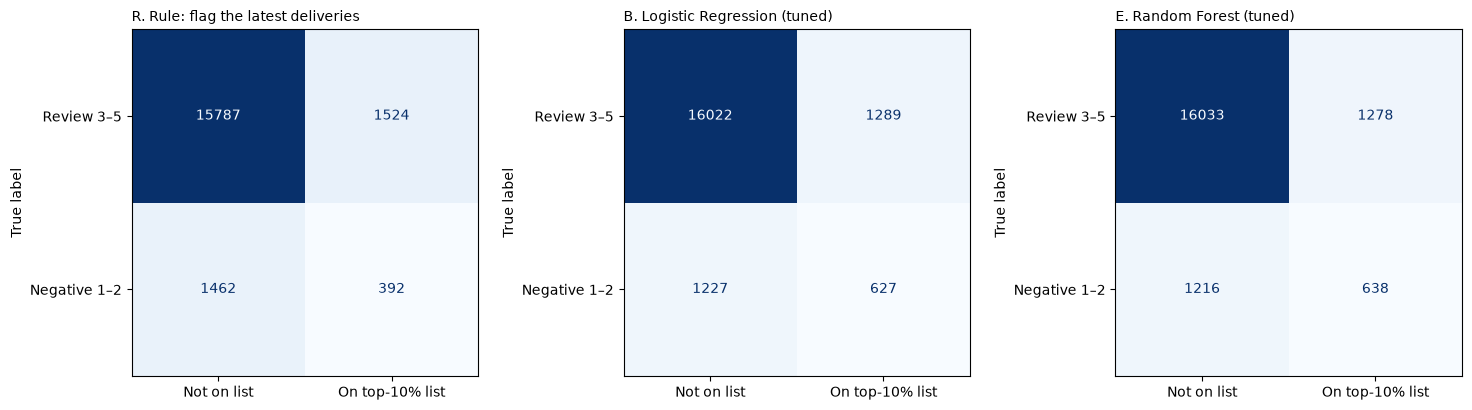

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, name in zip(axes, [RULE, B, E]):
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        top_list[name].astype(int),
        display_labels=["Review 3–5", "Negative 1–2"],
        cmap="Blues",
        colorbar=False,
        ax=ax,
    )
    ax.set_xticks([0, 1], ["Not on list", "On top-10% list"])
    ax.set_xlabel("")
    ax.set_title(name, loc="left", fontsize=10)
plt.tight_layout()
plt.show()

### What this tells us

* **All scores are lower on later orders,** mainly because there are fewer unhappy customers to find. Only 9.7% of test orders got a negative review (against about 14% in the practice exams), and only 3.4% were late. So a list of the riskiest 10% contains fewer genuinely unhappy customers, even for a good model.
* **The models still find unhappy customers far better than chance.** The tuned forest's top-10% list (1,916 orders) contains 638 real negative reviews: 33% precision, about **3.4× better** than contacting customers at random (9.7%). The list catches 34% of all negative reviews.
* **The models clearly beat the rule.** The rule's list contains only 392 negative reviews (20%). On later orders late deliveries are rare, so ranking by lateness quickly runs out of useful signal.
* **The four main models are almost tied.** A, B, D and E find between 622 and 638 negative reviews in their lists: a difference of 16 customers out of 1,916. The single tree (387) is no better than the rule.
* **F1 at the 0.50 cut-off is not a fair comparison here.** The tuned models were chosen without class weighting, so on later orders few of their scores reach 0.50, and they flag only short lists (recall 0.10–0.14). That is why the rule has a higher F1 (0.245). At the same list size (the top 10%) the models win clearly, which is exactly why Phase 1 chose precision among the top-ranked orders.

### 8.1 Train vs validation vs test

**What we are doing:** putting three scores side by side for every model:

* **Train:** the score on orders the model **learned from** (averaged over the five practice exams).
* **Validation:** the score on the practice exams it did **not** learn from (step 7).
* **Test:** the score on the final exam (this step).

**Why:** this is the standard check for **overfitting**. A model that is much better on train than on validation has memorised its training orders instead of learning patterns that carry over. Validation and test should be reasonably close; with a time split, some gap is expected because the test period is different.

In [13]:
train_validation_test = pd.DataFrame({
    "train top-10% precision": cv_table["train_top10_precision"],
    "validation top-10% precision": cv_table["top10_precision"],
    "test top-10% precision": test_table["top10_precision"],
    "train F1": cv_table["train_f1"],
    "validation F1": cv_table["f1"],
    "test F1": test_table["f1"],
}).loc[MODELS]
train_validation_test["top-10% gap: train − validation"] = (
    train_validation_test["train top-10% precision"] - train_validation_test["validation top-10% precision"]
)
display(train_validation_test.round(3))

,train top-10% precision,validation top-10% precision,test top-10% precision,train F1,validation F1,test F1,top-10% gap: train − validation
A. Logistic Regression (plain),0.453,0.541,0.325,0.343,0.438,0.201,-0.088
B. Logistic Regression (tuned),0.445,0.551,0.327,0.281,0.343,0.174,-0.106
C. Decision Tree (single tree),1.000,0.305,0.202,0.999,0.333,0.206,0.695
D. Random Forest (no tuning),1.000,0.550,0.331,0.999,0.418,0.223,0.450
E. Random Forest (tuned),0.603,0.561,0.333,0.359,0.419,0.210,0.042


### What this tells us

* **Logistic Regression does not overfit.** Its train scores are actually *lower* than its validation scores (gaps of −0.09 and −0.11). That is not a problem: the train scores are measured largely on the earlier, calmer periods, and precision is naturally lower when there are fewer unhappy customers to find.
* **Unrestricted trees memorise.** The single tree (C) and the untuned forest (D) score 1.000 on their training orders (F1 0.999), far above validation (0.305 and 0.550).
* **Tuning tames the forest.** E's train score (0.603) is close to its validation score (0.561), a gap of only 0.042.
* **Every model drops from validation to test,** because the test period has fewer unhappy customers and far fewer late orders (step 3). The four main models drop by a similar amount (about 0.22, from roughly 0.55 to 0.33), and the tuned forest stays on top, so the model choice holds.

## Step 9. Does each step up in complexity help, and do the models beat the rule?

**What we are doing:** checking every step up in complexity, plus the most important question of all: does the best model beat the simple rule?

| Step | From (simpler) | To (more complex) | Question |
|---|---|---|---|
| Logistic Regression | A. Plain | B. Tuned | Do regularisation and class weighting help? |
| Tree family, step 1 | C. Single tree | D. Random Forest | Does averaging 200 trees beat one tree? |
| Tree family, step 2 | D. Random Forest | E. Tuned Random Forest | Does tuning the forest help? |
| Model vs rule | R. Rule | The winner from step 7 | Is a model worth building at all? |

**The rule for "worth it":** the more complex option must beat the simpler one on **average top-10% precision** *and* in **at least 4 of the 5 practice exams**. Comparing exam by exam matters here: each exam covers a different period, so a single average can hide that one model only wins in one unusual period.

**Why:** a more complex model is harder to explain and maintain, so it has to earn its place. The project brief asks for exactly this check.

Logistic Regression: plain → tuned (A → B): WORTH IT
Tree family: single tree → forest (C → D): WORTH IT
Tree family: forest → tuned forest (D → E): WORTH IT
Best model vs the rule (R → E): WORTH IT


,CV top-10% simpler,CV top-10% more complex,average gain,exams won (of 5),better on test,verdict
step,,,,,,
Logistic Regression: plain → tuned,0.541,0.551,0.010,4,"3 of 5: Top-10% precision, Top-10% recall, PR-AUC",Worth it
Tree family: single tree → forest,0.305,0.550,0.245,5,"5 of 5: Top-10% precision, Top-10% recall, F1-...",Worth it
Tree family: forest → tuned forest,0.550,0.561,0.010,5,"4 of 5: Top-10% precision, Top-10% recall, AUC...",Worth it
Best model vs the rule,0.501,0.561,0.060,4,"4 of 5: Top-10% precision, Top-10% recall, AUC...",Worth it


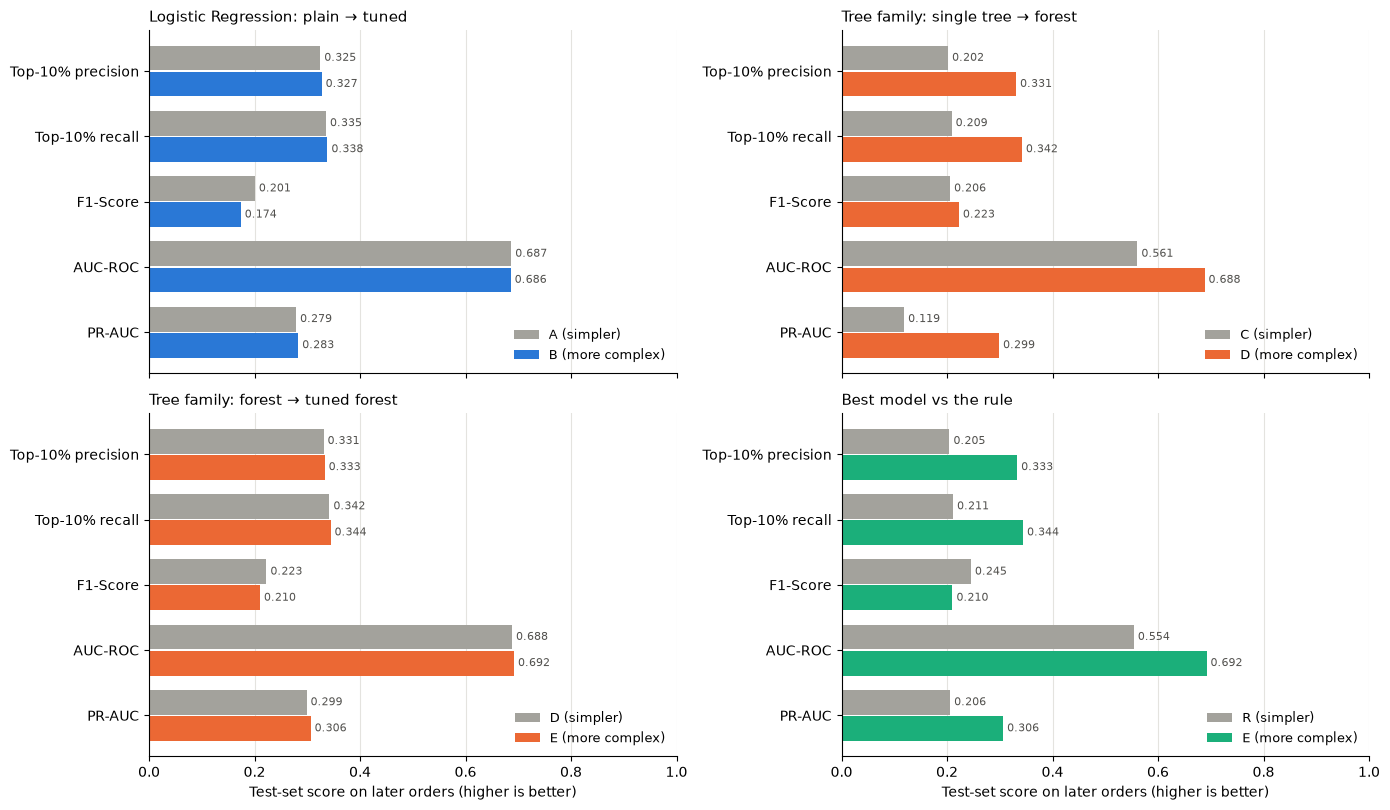

In [14]:
COMPLEXITY_STEPS = [
    ("Logistic Regression: plain → tuned", A, B, "#2a78d6"),
    ("Tree family: single tree → forest", C, D, "#eb6834"),
    ("Tree family: forest → tuned forest", D, E, "#eb6834"),
    ("Best model vs the rule", RULE, FINAL, "#1baf7a"),
]
TEST_METRICS = {"top10_precision": "Top-10% precision", "top10_recall": "Top-10% recall", "f1": "F1-Score", "roc_auc": "AUC-ROC", "pr_auc": "PR-AUC"}

summary_rows = []
for step, simpler, complex_model, _ in COMPLEXITY_STEPS:
    gain = cv_table.loc[complex_model, "top10_precision"] - cv_table.loc[simpler, "top10_precision"]
    exams_won = int((cv_folds[complex_model] > cv_folds[simpler]).sum())
    improved = [label for metric, label in TEST_METRICS.items() if test_table.loc[complex_model, metric] > test_table.loc[simpler, metric]]
    verdict = "Worth it" if gain > 0 and exams_won >= 4 else "Not worth it"
    summary_rows.append({
        "step": step,
        "CV top-10% simpler": cv_table.loc[simpler, "top10_precision"],
        "CV top-10% more complex": cv_table.loc[complex_model, "top10_precision"],
        "average gain": gain,
        "exams won (of 5)": exams_won,
        "better on test": f"{len(improved)} of 5: {', '.join(improved)}",
        "verdict": verdict,
    })
    print(f"{step} ({simpler[:1]} → {complex_model[:1]}): {verdict.upper()}")
display(pd.DataFrame(summary_rows).set_index("step").round(3))

fig, axes = plt.subplots(2, 2, figsize=(14, 8.2), sharex=True)
for ax, (step, simpler, complex_model, color) in zip(axes.ravel(), COMPLEXITY_STEPS):
    comparison = pd.DataFrame({
        simpler[:1] + " (simpler)": test_table.loc[simpler, list(TEST_METRICS)],
        complex_model[:1] + " (more complex)": test_table.loc[complex_model, list(TEST_METRICS)],
    }).rename(index=TEST_METRICS)
    positions = np.arange(len(comparison))[::-1]
    for offset, column, bar_color in [(0.2, comparison.columns[0], "#a3a29c"), (-0.2, comparison.columns[1], color)]:
        ax.barh(positions + offset, comparison[column], height=0.38, color=bar_color, label=column)
        for y_position, value in zip(positions + offset, comparison[column]):
            ax.text(value, y_position, f" {value:.3f}", va="center", fontsize=8, color="#52514e")
    ax.set_yticks(positions, comparison.index)
    ax.set_xlim(0, 1)
    ax.set_title(step, loc="left", fontsize=11)
    ax.legend(loc="lower right", frameon=False, fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="x", color="#e4e3df", linewidth=0.8)
    ax.set_axisbelow(True)
for ax in axes[-1]:
    ax.set_xlabel("Test-set score on later orders (higher is better)")
plt.tight_layout()
plt.show()

### What this tells us

* **All four steps pass the rule, but by very different margins:**
  * **Single tree → forest (C → D): a huge gain** (+0.245, winning all 5 exams). One tree is not good enough; averaging 200 trees fixes it.
  * **Best model vs the rule (R → E): a clear gain** (+0.060 on average, winning 4 of 5 exams; 0.333 vs 0.205 on later orders). Building a model is worth it. The rule only wins exam 4, the period with many late deliveries.
  * **Plain → tuned Logistic Regression (A → B) and forest → tuned forest (D → E): small gains** (+0.010 each). They pass the rule (B wins 4 of 5 exams, E wins all 5), but on later orders they add only 5 and 4 extra unhappy customers to a 1,916-order list.
* **What this means:** most of the value comes from using a sensible model (anything except a single tree) instead of the rule. Tuning adds a little on top.

**Likely question:** *"If tuning adds so little, why bother?"* **Answer:** it is cheap, it improves the forest in every one of the five practice exams, and it controls overfitting. The tuned forest's train–validation gap is 0.042, against 0.450 for the untuned forest.

## Step 10. What do the models rely on?

A model that cannot be explained is hard to trust. We look at this from two angles.

### 10.1 Logistic Regression weights (tuned model, B)

**What we are doing:** reading the weights of the tuned Logistic Regression.

* A **positive** weight raises the risk; a **negative** weight lowers it.
* The **odds ratio** turns a weight into plain English: 1.5 means about **50% higher odds** of a negative review, and 0.8 means 20% lower odds, with every other input held the same. For numbers, this is per one "typical step" up (one standard deviation).
* `training_orders` shows how many training orders have that category (blank for numbers). A big weight resting on very few orders is fragile.

The first table shows the 10 strongest pushes down and the 10 strongest pushes up. The second shows what tuning did to the **plain** model's (A) five largest weights.

In [15]:
def weight_table(model):
    preprocessor = model.named_steps["preprocessor"]
    encoded = preprocessor.transform(X_train)
    table = pd.DataFrame({
        "input": preprocessor.get_feature_names_out(),
        "weight": model.named_steps["classifier"].coef_[0],
        "training_orders": np.asarray((encoded != 0).sum(axis=0)).ravel().astype(float),
    })
    table["odds_ratio"] = np.exp(table["weight"])
    table.loc[table["input"].isin(DELIVERED_NUMERIC_FEATURES), "training_orders"] = np.nan
    return table[["input", "weight", "odds_ratio", "training_orders"]]


tuned_weights = weight_table(fitted[B])
display(
    pd.concat([tuned_weights.nsmallest(10, "weight"), tuned_weights.nlargest(10, "weight")])
    .drop_duplicates()
    .sort_values("weight")
    .reset_index(drop=True)
    .round(3)
)

plain_weights = weight_table(fitted[A])
largest_plain = plain_weights.loc[plain_weights["weight"].abs().nlargest(5).index]
print("What tuning did to the plain model's five largest weights:")
display(pd.DataFrame({
    "input": largest_plain["input"].to_numpy(),
    "training_orders": largest_plain["training_orders"].to_numpy(),
    "odds_ratio_plain": largest_plain["odds_ratio"].to_numpy(),
    "odds_ratio_tuned": tuned_weights.set_index("input").loc[largest_plain["input"], "odds_ratio"].to_numpy(),
}).round(3))

,input,weight,odds_ratio,training_orders
0,purchase_month_2018-05,-0.066,0.936,6077.0
1,days_early,-0.061,0.941,NaN
2,primary_product_category_sports_leisure,-0.043,0.958,6200.0
3,purchase_month_2017-08,-0.040,0.961,4165.0
4,customer_state_RS,-0.039,0.962,4393.0
5,primary_product_category_garden_tools,-0.039,0.962,2951.0
6,seller_state_MG,-0.038,0.963,6251.0
7,purchase_month_2017-09,-0.038,0.963,4118.0
8,primary_product_category_stationery,-0.036,0.965,1753.0
9,purchase_month_2017-07,-0.030,0.971,3842.0


What tuning did to the plain model's five largest weights:


,input,training_orders,odds_ratio_plain,odds_ratio_tuned
0,primary_product_category_food_drink,179.0,0.259,0.985
1,primary_product_category_fashion_male_clothing,91.0,3.677,1.014
2,primary_product_category_books_general_interest,397.0,0.404,0.978
3,same_state_False,49911.0,0.495,0.994
4,same_state_True,26748.0,0.511,1.004


### What this tells us

* **Delivery timing and order size push risk up.** The strongest positive weights are all numbers: `late_delivery_flag` (odds ratio 1.67, so late orders have about **67% higher odds** of a negative review), `delivery_days` (1.36), `item_count` (1.26) and `seller_count` (1.19). `days_early` has a small negative weight (0.94): arriving earlier lowers the risk a little.
* **`purchase_month` picks up period effects.** February and March 2018, the bad period, push the risk up (1.07), and some other months push it down. Those months never come back, so this does not help with future orders, which is consistent with step 12, where removing `purchase_month` changes nothing.
* **Product categories and states have small effects** (odds ratios 0.96–1.13), each resting on at least 1,753 training orders.
* **Tuning fixed a real weakness of the plain model.** Its biggest weights sat on **rare categories**, such as `food_drink` (179 orders, odds ratio 0.26) and `fashion_male_clothing` (91 orders, 3.68), and on the pair `same_state_False` / `same_state_True`, which carry the same information twice. Tuning's regularisation (`C=0.001`) pulled all five back to almost no effect (0.98–1.01).
* These are **associations, not causes**.

### 10.2 Permutation importance: both finalists side by side

Random Forest has no weights to read, so to compare the two families **like for like** we use **permutation importance** on both.

**What we are doing:** for one input at a time (say `delivery_days`), we **shuffle its values randomly** between test orders, which breaks its link to the outcome, and measure how much the model's ranking quality (PR-AUC) drops. A big drop means the model relies on that input; no drop means it barely uses it. Each input is shuffled 5 times and the drops are averaged.

**Why:** it works the same way for any model, and it uses the original 21 inputs, so it is easy to read.

,logistic_regression_pr_auc_drop,random_forest_pr_auc_drop
days_early,0.0021,0.0847
item_count,0.0292,0.0288
late_delivery_flag,0.0881,0.0207
seller_count,0.0232,0.0119
delivery_days,0.0362,0.0074
primary_product_category,0.0021,0.0046
product_volume_cm3_mean,0.0001,0.0030
order_freight_value,-0.0007,0.0021
payment_total,-0.0001,0.0019
order_item_value,0.0001,0.0019


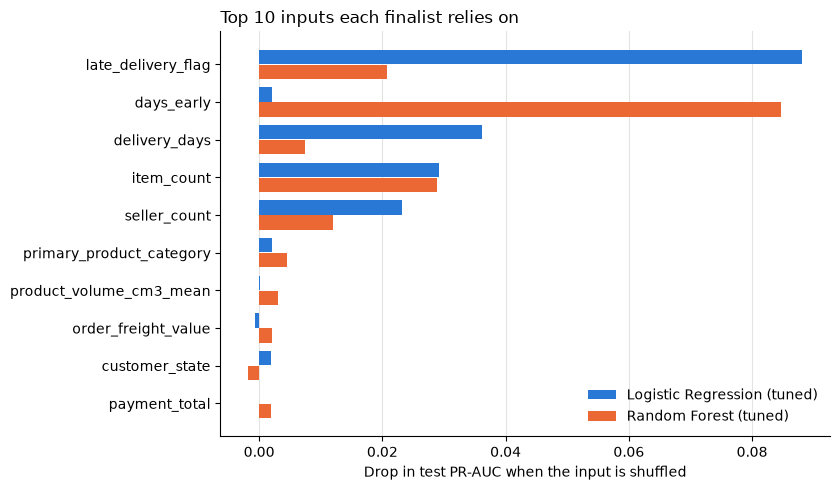

In [16]:
importance_columns = {}
for name in [B, E]:
    result = permutation_importance(
        fitted[name], X_test, y_test, scoring="average_precision", n_repeats=5, random_state=RANDOM_SEED,
    )
    importance_columns[name] = pd.Series(result.importances_mean, index=X_test.columns)

importance_table = (
    pd.DataFrame(importance_columns)
    .rename(columns={B: "logistic_regression_pr_auc_drop", E: "random_forest_pr_auc_drop"})
    .sort_values("random_forest_pr_auc_drop", ascending=False)
)
display(importance_table.round(4))

top = importance_table.loc[importance_table.max(axis=1).nlargest(10).index].iloc[::-1]
positions = np.arange(len(top))
fig, ax = plt.subplots(figsize=(8.5, 5))
ax.barh(positions + 0.2, top["logistic_regression_pr_auc_drop"], height=0.38, color="#2a78d6", label="Logistic Regression (tuned)")
ax.barh(positions - 0.2, top["random_forest_pr_auc_drop"], height=0.38, color="#eb6834", label="Random Forest (tuned)")
ax.set_yticks(positions, top.index)
ax.set_xlabel("Drop in test PR-AUC when the input is shuffled")
ax.set_title("Top 10 inputs each finalist relies on", loc="left")
ax.legend(loc="lower right", frameon=False)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="x", color="#e4e3df", linewidth=0.8)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

### What this tells us

* **Both families agree: delivery timing first, then order size.** Logistic Regression relies most on `late_delivery_flag` (drop 0.088), `delivery_days` (0.036), `item_count` (0.029) and `seller_count` (0.023). The Random Forest relies most on `days_early` (0.085), `item_count` (0.029), `late_delivery_flag` (0.021) and `seller_count` (0.012). Every other input adds less than 0.005.
* **They use the timing information differently.** Logistic Regression leans on the yes/no late flag and barely uses `days_early` (0.002). The Random Forest relies most on `days_early`, *how many days* early or late the order was. This matches the "cliff at zero" that Phase 1 found: satisfaction drops from the very first day late, and arriving early stops helping after about a week. A tree can learn that shape; a straight line cannot.
* **Order size is the second signal for both families** (`item_count` and `seller_count`). Phase 1 noted that a single Olist order may involve several sellers and arrive in separate shipments, which is a plausible reason but not tested here.
* **Payment, product details, geography and `purchase_month` add almost nothing.** This is consistent with Phase 1, which found that monetary variables barely move review scores and that geography acts through delivery time.
* **Caution:** the timing inputs overlap, so each one looks less important on its own than delivery timing is as a group. This shows what the models **rely on**, not what **causes** negative reviews.

## Step 11. Error analysis: where does the model go wrong?

**What we are doing:** an overall score can hide big differences. Here we take the winning model's **top-10% contact list** on the test set and check who is on it, split into groups:

1. **By delivery timing:** from "late by 4+ days" to "early by 7+ days".
2. **By order size:** 1 item vs 2 or more items.
3. **Who we catch, who we miss, and who we contact unnecessarily:** what those orders look like.

**Why:** this shows *where* the model is useful and where it is blind, which matters more to customer service than one average score.

In [17]:
other_finalist = B if FINAL == E else E
final_list = top_list[FINAL]
other_list = top_list[other_finalist]
print(f"Winning model: {FINAL}. Recall of the other finalist ({other_finalist[:1]}) and the rule shown for comparison.")


def segment_report(segment, segment_name):
    frame = pd.DataFrame({
        segment_name: segment, "actual": actual_negative,
        "final": final_list, "other": other_list, "rule": top_list[RULE],
    })
    rows = []
    for value, group in frame.groupby(segment_name, observed=True):
        negatives = group["actual"].sum()
        caught = (group["actual"] & group["final"]).sum()
        rows.append({
            segment_name: value,
            "test orders": len(group),
            "negative-review rate": group["actual"].mean(),
            "share on list": group["final"].mean(),
            "recall (winner)": caught / negatives if negatives else np.nan,
            "precision (winner)": caught / group["final"].sum() if group["final"].sum() else np.nan,
            "negatives missed": int(negatives - caught),
            f"recall ({other_finalist[:1]})": (group["actual"] & group["other"]).sum() / negatives if negatives else np.nan,
            "recall (rule)": (group["actual"] & group["rule"]).sum() / negatives if negatives else np.nan,
        })
    return pd.DataFrame(rows).set_index(segment_name)


timing_labels = ["Late by 4+ days", "Late by 1–3 days", "On the promised day", "Early by 1–6 days", "Early by 7+ days"]
days_early = X_test["days_early"].to_numpy()
timing = pd.Categorical(
    np.select([days_early <= -4, days_early < 0, days_early == 0, days_early < 7], timing_labels[:4], default=timing_labels[4]),
    categories=timing_labels,
    ordered=True,
)
print("1. By delivery timing")
display(segment_report(timing, "delivery timing").round(3))

order_size = pd.Categorical(np.where(X_test["item_count"] >= 2, "2+ items", "1 item"), categories=["1 item", "2+ items"], ordered=True)
print("2. By order size")
display(segment_report(order_size, "order size").round(3))

outcome_labels = [
    "Caught: negative review, on the list",
    "Missed: negative review, not on the list",
    "Unnecessary contact: happy customer, on the list",
    "Correctly left off the list",
]
outcome = pd.Categorical(
    np.select(
        [actual_negative & final_list, actual_negative & ~final_list, ~actual_negative & final_list],
        outcome_labels[:3],
        default=outcome_labels[3],
    ),
    categories=outcome_labels,
    ordered=True,
)
print("3. What caught, missed and unnecessarily contacted orders look like (winning model)")
display(
    X_test.assign(outcome=outcome)
    .groupby("outcome", observed=True)
    .agg(
        orders=("days_early", "size"),
        share_delivered_late=("late_delivery_flag", "mean"),
        median_days_early=("days_early", "median"),
        median_delivery_days=("delivery_days", "median"),
        share_with_2plus_items=("item_count", lambda items: (items >= 2).mean()),
    )
    .round(3)
)

Winning model: E. Random Forest (tuned). Recall of the other finalist (B) and the rule shown for comparison.
1. By delivery timing


,test orders,negative-review rate,share on list,recall (winner),precision (winner),negatives missed,recall (B),recall (rule)
delivery timing,,,,,,,,
Late by 4+ days,364,0.670,1.000,1.000,0.670,0,1.000,1.00
Late by 1–3 days,293,0.218,0.993,0.984,0.216,1,1.000,1.00
On the promised day,344,0.073,0.084,0.080,0.069,23,0.160,1.00
Early by 1–6 days,3684,0.076,0.046,0.107,0.175,251,0.142,0.21
Early by 7+ days,14480,0.086,0.073,0.241,0.282,941,0.222,0.00


2. By order size


,test orders,negative-review rate,share on list,recall (winner),precision (winner),negatives missed,recall (B),recall (rule)
order size,,,,,,,,
1 item,17349,0.082,0.040,0.210,0.428,1128,0.228,0.253
2+ items,1816,0.235,0.669,0.793,0.278,88,0.709,0.073


3. What caught, missed and unnecessarily contacted orders look like (winning model)


,orders,share_delivered_late,median_days_early,median_delivery_days,share_with_2plus_items
outcome,,,,,
"Caught: negative review, on the list",638,0.481,4.0,12.5,0.530
"Missed: negative review, not on the list",1216,0.001,13.0,8.0,0.072
"Unnecessary contact: happy customer, on the list",1278,0.272,10.0,9.0,0.686
Correctly left off the list,16033,0.000,13.0,7.0,0.032


### What this tells us

* **The contact list is built from two kinds of order.** Every late order makes the list (100% of orders 4+ days late and 99% of those 1–3 days late), and they supply about half of the list's hits (48%). Most of the remaining places go to **multi-item orders**: 67% of orders with 2+ items are on the list, against 4% of single-item orders.
* **The list works best on very late orders.** 67% of orders that were 4+ days late got a negative review, and the model catches all of them. But this is also where the known issue in step 2.1 matters most.
* **On-time and early orders are the blind spot.** They are 97% of test orders and hold 1,215 of the 1,216 negative reviews the model misses; it catches only 8–24% of their negative reviews. These customers were unhappy for reasons the data does not show, such as product quality, wrong items or seller communication. Phase 1 found the same: two-thirds of bad reviews are on on-time orders, so fixing delivery alone addresses under a third of them.
* **Unnecessary contacts are mostly multi-item orders:** 69% of the 1,278 happy customers on the list had 2+ items.
* **Compared with the rule:** the rule catches every negative review on late and on-the-day orders, but almost none of the multi-item problems (recall 7% on 2+-item orders, against 79% for the model). The model's advantage over the rule comes mainly from multi-item orders.
* **What this means for customer service:** the list is a late-delivery alarm plus a multi-item warning. Finding unhappy customers whose delivery went well would need other data, such as returns, complaints or seller ratings.

## Step 12. How much would a random split have flattered the models?

**What we are doing:** re-running every model with the **random, stratified 80/20 split** that the team's earlier notebooks used, with the same settings, and comparing the scores with our time-based results. We also check `purchase_month`, the one input tied to the calendar, by blanking it out for the two finalists on the time-based split.

**Why:** this measures the **temporal leakage** our Phase 1 literature review warned about. If random-split scores are much higher, a random split would have overstated how well the model works on future orders.

In [18]:
X_random_train, X_random_test, y_random_train, y_random_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_SEED,
)
random_rows = {}
for name in MODELS:
    model = clone(fitted[name]).fit(X_random_train, y_random_train)
    scores = model.predict_proba(X_random_test)[:, 1]
    random_rows[name] = evaluate(y_random_test, scores, scores >= THRESHOLD)
random_rows[RULE] = evaluate(y_random_test, rule_scores(X_random_test), rule_flags(X_random_test))
random_table = pd.DataFrame(random_rows).T.loc[[RULE] + MODELS]
print(f"Random split test set: negative-review rate {y_random_test.mean():.1%}; time-based test set: {y_test.mean():.1%}")
display(pd.DataFrame({
    "top-10% precision: time split": test_table["top10_precision"],
    "top-10% precision: random split": random_table["top10_precision"],
    "F1: time split": test_table["f1"],
    "F1: random split": random_table["f1"],
    "AUC-ROC: time split": test_table["roc_auc"],
    "AUC-ROC: random split": random_table["roc_auc"],
}).loc[[RULE] + MODELS].round(3))

print("Effect of blanking out purchase_month (time-based split, finalists only)")
blanked = {"purchase_month": "all months"}
month_rows = {}
for name in [B, E]:
    model = clone(fitted[name]).fit(X_train.assign(**blanked), y_train)
    scores = model.predict_proba(X_test.assign(**blanked))[:, 1]
    month_rows[name] = {
        "top-10% precision with purchase_month": test_table.loc[name, "top10_precision"],
        "top-10% precision without": top_share_precision(y_test, scores),
        "PR-AUC with purchase_month": test_table.loc[name, "pr_auc"],
        "PR-AUC without": average_precision_score(y_test, scores),
    }
display(pd.DataFrame(month_rows).T.round(3))

Random split test set: negative-review rate 12.8%; time-based test set: 9.7%


,top-10% precision: time split,top-10% precision: random split,F1: time split,F1: random split,AUC-ROC: time split,AUC-ROC: random split
R. Rule: flag the latest deliveries,0.205,0.467,0.245,0.436,0.554,0.671
A. Logistic Regression (plain),0.325,0.533,0.201,0.427,0.687,0.750
B. Logistic Regression (tuned),0.327,0.532,0.174,0.425,0.686,0.748
C. Decision Tree (single tree),0.202,0.314,0.206,0.332,0.561,0.618
D. Random Forest (no tuning),0.331,0.531,0.223,0.439,0.688,0.755
E. Random Forest (tuned),0.333,0.546,0.210,0.426,0.692,0.767


Effect of blanking out purchase_month (time-based split, finalists only)


,top-10% precision with purchase_month,top-10% precision without,PR-AUC with purchase_month,PR-AUC without
B. Logistic Regression (tuned),0.327,0.325,0.283,0.283
E. Random Forest (tuned),0.333,0.336,0.306,0.309


### What this tells us

* **A random split would have flattered every model.** Top-10% precision on the random split is 0.53–0.55 for the main models, against about 0.33 on later orders. AUC-ROC, which does not depend on how many negatives there are, also drops: from 0.767 to 0.692 for the tuned forest. This is the temporal leakage our Phase 1 literature review warned about.
* **Part of the gap is the test period itself**, which has fewer negative reviews (9.7% vs 12.8%). But the AUC-ROC drop shows the models also genuinely rank less well on a new period.
* **The rule suffers most** (0.467 → 0.205), because late deliveries became rare. The models fall less, so their advantage over the rule is actually **bigger** on later orders (+0.128 against +0.079 on the random split).
* **The random split would also have overstated the forest's lead over Logistic Regression:** 0.546 vs 0.532 on the random split, but only 0.333 vs 0.327 on later orders. This echoes Kapoor & Narayanan (2023): correcting leakage shrinks the gap between complex and simple models.
* **`purchase_month` adds nothing.** Removing it changes top-10% precision by at most 0.003 for either finalist (the forest is even slightly better without it), so it can be dropped.

## Step 13. Final comparison: tuned Logistic Regression vs tuned Random Forest

**What we are doing:** comparing the best model of each family on every score, with the rule as a reference. The last column names the better finalist on each row (higher is better for all of them).

In [19]:
FINAL_ROWS = {
    "CV top-10% precision (average of 5 exams)": ("cv", "top10_precision"),
    "Test top-10% precision": ("test", "top10_precision"),
    "Test top-10% recall": ("test", "top10_recall"),
    "Test PR-AUC": ("test", "pr_auc"),
    "Test AUC-ROC": ("test", "roc_auc"),
    "Test F1 at the 0.50 cut-off": ("test", "f1"),
    "Test balanced accuracy at the 0.50 cut-off": ("test", "balanced_accuracy"),
}
sources = {"cv": cv_table, "test": test_table}
head_to_head = pd.DataFrame({
    name: {label: sources[source].loc[name, metric] for label, (source, metric) in FINAL_ROWS.items()}
    for name in [B, E, RULE]
})
head_to_head["better finalist"] = np.where(head_to_head[E] > head_to_head[B], "Random Forest", "Logistic Regression")
display(head_to_head.round(3))
print(f"Notebook runtime: {(time.perf_counter() - notebook_started) / 60:.1f} minutes")

,B. Logistic Regression (tuned),E. Random Forest (tuned),R. Rule: flag the latest deliveries,better finalist
CV top-10% precision (average of 5 exams),0.551,0.561,0.501,Random Forest
Test top-10% precision,0.327,0.333,0.205,Random Forest
Test top-10% recall,0.338,0.344,0.211,Random Forest
Test PR-AUC,0.283,0.306,0.206,Random Forest
Test AUC-ROC,0.686,0.692,0.554,Random Forest
Test F1 at the 0.50 cut-off,0.174,0.210,0.245,Random Forest
Test balanced accuracy at the 0.50 cut-off,0.547,0.559,0.573,Random Forest


Notebook runtime: 10.0 minutes


### What this tells us: the final choice is the tuned Random Forest (E), by a small margin

**How it was chosen:** by the rule fixed in step 7, before the test set was opened: the highest average top-10% precision across the five time-ordered practice exams. The tuned Random Forest won (0.561 vs 0.551 for the tuned Logistic Regression), and on later orders it beats the tuned Logistic Regression on every measure in the table above.

**How to defend this choice:**

1. **It ranks unhappy customers best,** both in the practice exams and on later orders: top-10% precision 0.333 vs 0.327, PR-AUC 0.306 vs 0.283, and AUC-ROC 0.692 vs 0.686.
2. **It is clearly worth building over the simple rule.** Its top-10% list finds 638 unhappy customers, against 392 for "contact the latest deliveries": 63% more.
3. **It was tested fairly.** It was trained only on the past and tested on the future, with the same tuning effort as Logistic Regression and the same practice exams.
4. **Its reasoning makes sense.** Both families rely on delivery timing and order size, in line with the Phase 1 findings.
5. **It overfits only a little after tuning** (train 0.603 vs validation 0.561).

**Be honest about the margin.** On later orders the tuned forest's list finds 638 unhappy customers, against 634 (untuned forest), 627 (tuned Logistic Regression) and 622 (plain Logistic Regression). A team that values simplicity and explainability could reasonably choose the tuned Logistic Regression and lose very little.

**What it costs compared with Logistic Regression:** it is harder to explain (no weights, so it needs permutation importance), it is slower to train, and its model file is much bigger.

**Before relying on it:**

* The known issue in step 2.1 may lower all scores, especially on late orders, once it is fixed.
* Expect about 33% precision on the contact list in a period like mid-2018. It will be higher when more orders are late or more customers are unhappy.
* It cannot find unhappy customers whose delivery went well (step 11).

## Step 14. A note on the saved model files

The `.pkl` files in `deployment/` (`delivered_order_negative_review_pipeline.pkl` and `delivered_order_random_forest_pipeline.pkl`) were made by the team's earlier notebooks, which used the **random split** and chose settings by F1. This notebook does not overwrite them.

**Once the team has settled the known issue in step 2.1 and agreed the final model, that model should be retrained and saved again**, so that Phase 3 deploys the model this notebook actually selects.